# ML Lab Part II – Model Training & Hyperparameter Optimization

## Goal
Train different classification algorithms on the feature dataset from Part I
and optimize their hyperparameters.

## Workflow
```
Load data → Train/Test-Split → Train classifier →
Measure performance → Optimize hyperparameters
```

**Prerequisite:** `data/feature_data.csv` from Part I must exist.

## Setup

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = Path("data")
ACTIVITIES = {1: "Walking", 2: "Standing", 3: "Squats", 4: "SpinAround"}

---
## Task 1 – Load data

Load the feature dataset from Part I. We start with the one that provides only the 4 activities. 

**Hint:** `pd.read_csv()`, vizualize at the table, then separate features (X) and labels (y).
The `label` column contains the class labels.

In [41]:
# TODO: load feature_data.csv
# X = all columns except 'label'
# y = 'label' column
df = pd.read_csv('data/feature_data.csv')
X  = df.iloc[:,:-1] # iloc helps slice pandas datasets
y  = df.iloc[:,-1]

print(f"Dataset: {X.shape[0]} Samples, {X.shape[1]} Features")
print(f"Classes: {np.unique(y)}")



Dataset: 561 Samples, 24 Features
Classes: [1. 2. 3. 4.]


---
## Task 2 – Train/Test-Split

Split the dataset into **85% training** and **15% test**.
The test split is not used for training. In this lab, we will also inspect it once in Task 3 to compare it with cross-validation, but do not use it to choose or tune models.

**Hints:**
- use `stratify=y` to ensure that all classes are distributed evenly

In [42]:
# TODO: split the dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15,random_state=3,stratify=y)

print(f"Training:  {X_train.shape[0]} Samples")
print(f"Test:      {X_test.shape[0]} Samples")

Training:  476 Samples
Test:      85 Samples


In [43]:
#train_test_split?

---
## Task 3 – Train and compare classifiers

Train at least the following three classifiers on the training data:

| Class | sklearn |
|---|---|
| Decision Tree | `DecisionTreeClassifier()` |
| k-Nearest Neighbors | `KNeighborsClassifier()` |
| Random Forest | `RandomForestClassifier()` |

For each classifier:
- **a)** Training on `X_train` / `y_train`
- **b)** Training-Accuracy (Resubstitution) with `model.score(X_train, y_train)`
- **c)** Cross-Validation-Accuracy (5-fold) with `cross_val_score(..., cv=5)`
- **d)** Test-Accuracy with `model.score(X_test, y_test)`

**Own research:** We did not cover `cross_val_score` in detail in the lecture. Familiarize yourself with the goal of **k-fold cross validation**: Why is the training data split into several folds, why is a fresh model trained for each fold, and why can this give a better estimate than only checking the training accuracy?

**Hint:** `cross_val_score` returns an array; use the mean with `.mean()`.
Compare the cross-validation accuracy with the test accuracy. This test-score comparison is included here for learning purposes only. In a clean ML workflow, the test set should not be used to choose between models or tune hyperparameters.

Is there a difference between cross-validation accuracy and test accuracy in your case? If yes, what could explain it?

<div style="border: 1px solid #100e0e; padding: 10px; min-height: 120px; background: #080808;">
<strong>Your explanation:</strong><br><br>
Yes there is a difference between test accuracy and cv score. The reason for this is that cross validation creates various subsets of mini train & test data within our training data + labels and then runs the score function on each one of them. This is a much better approach than considering the score of a single test train split since we could have gotten lucky with fairly similar data as our training data etc. We then can take the average of each subset's score and get a much better understanding of our accuracy. This is very helpful when you already have less data to begin with (like here). Note - CV truly checks model quality as it also involves a fit i.e training step within. So it trains a model on the new subset of training data and then checks it against the new subset of test data for each subset.
</div>

In [54]:
models = {
    "Decision Tree":  DecisionTreeClassifier(random_state=42),
    "k-NN":           KNeighborsClassifier(),
    "Random Forest":  RandomForestClassifier(random_state=42),
}

cv = {}
score_test = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score_training = model.score(X_train, y_train)
    score_test[name] = model.score(X_test, y_test)
    cv[name] = cross_val_score(model, X_train, y_train).mean() # it's 5 by default
    # NOTE: Must run cross validation only on training data!
    print(f"{name:<20} Resub: {score_training:.3f}  CV:{cv[name]:.3f}  Test: {score_test[name]:.3f}")
    # :<20 means left align with the field width of 20
#Train and evaluate all models An Output similar to this (values might differ)
#Decision Tree         Resub: 1.000  CV: 0.982 Test: 0.960
#k-NN                  Resub: 0.996  CV: 0.993 Test: 1.000
#Random Forest         Resub: 1.000  CV: 0.993 Test: 1.000

Decision Tree        Resub: 1.000  CV:0.922  Test: 0.953
k-NN                 Resub: 0.954  CV:0.933  Test: 0.941
Random Forest        Resub: 1.000  CV:0.958  Test: 0.965


In [45]:
# DecisionTreeClassifier?

---
## Task 4 – Compare with another group's data

Ask another group for their feature dataset from Part I and use it as an additional check: Are the cross-validation results from your own training data comparable to the accuracy on data recorded by another group?

Use this exact filename so everyone follows the same convention:

```text
data/feature_data_joint.csv
```

The file must have the same structure as your own `feature_data.csv`: the same feature columns and a `label` column with the same activity labels.

Evaluate the models from Task 3 on this joint dataset and compare the result with the CV accuracy from Task 3.

If the joint accuracy is much lower than the CV accuracy, investigate the reason: Join your dataset and the joint dataset, train new classifiers on the joined data, and compare whether the results improve. This can show whether the original model learned patterns that were too specific to your own group's recordings.

<div style="border: 1px solid #999; padding: 10px; min-height: 120px; background: #121212;">
<strong>Your explanation:</strong><br><br>
Are the joint-data accuracies comparable to the cross-validation accuracies? Does training on the joined dataset improve the result? What could explain the difference?

Yes the joint data accuracies are comparable to the external data set. Training on the joint data set does improve the result compared to the external dataset but only slightly. I believe the reason for this difference is the fact that we first have twice the amount of data so our model is better because of it. More importantly, we have the original data which the model was trained on (our data) present inside the joint data which we are validating against.
</div>

In [52]:
external_file = DATA_DIR / "feature_data_external.csv"

# TODO: load the external feature dataset
ext_pd = pd.DataFrame(pd.read_csv(external_file))
#display(pd.DataFrame(ext_pd))

# TODO: create X_external and y_external
X_external = ext_pd.iloc[:,:-1]
y_external = ext_pd.iloc[:,-1]
# print(X_external.shape)
# print(y_external.shape)

# TODO: evaluate each model from Task 3 on the external dataset
cv_ext = {}
print(f"{'-'*5} External Data {'-'*5}")
for name, model in models.items():
    score_test = model.score(X_external, y_external)
    cv_ext[name] = cross_val_score(model, X_external, y_external).mean()
    print(f"{name:<20} CV: {cv_ext[name]:.3f}  Test: {score_test:.3f}")
    
print()
# TODO: compare external accuracy with the CV accuracy from Task 3
for name in cv.keys():
    print(f'Own Data CV: {cv[name]:<7.3f} External Data CV: {cv_ext[name]:.3f}')

# TODO: join your dataset and the external dataset
X_joint = pd.concat([X, X_external])
y_joint = pd.concat([y, y_external])

print()
# TODO: train new classifiers on the joined dataset
cv_joint = {}
print(f"{'-'*5} Joint Data {'-'*5}")
for name, model in models.items():
    score_training = model.score(X_joint, y_joint)
    score_test = model.score(X_joint, y_joint)
    cv_joint[name] = cross_val_score(model, X_joint, y_joint).mean()
    print(f"{name:<20} CV: {cv_joint[name]:.3f}  Test: {score_test:.3f}")

print()

# TODO: compare the new CV accuracy with the previous external accuracy
for name in cv.keys():
    print(f'External Data CV: {cv_ext[name]:<7.3f} Joint Data CV: {cv_joint[name]:.3f}')


----- External Data -----
Decision Tree        CV: 0.843  Test: 0.296
k-NN                 CV: 0.925  Test: 0.243
Random Forest        CV: 0.936  Test: 0.481

Own Data CV: 0.922   External Data CV: 0.843
Own Data CV: 0.933   External Data CV: 0.925
Own Data CV: 0.958   External Data CV: 0.936

----- Joint Data -----
Decision Tree        CV: 0.843  Test: 0.727
k-NN                 CV: 0.887  Test: 0.682
Random Forest        CV: 0.929  Test: 0.799

External Data CV: 0.843   Joint Data CV: 0.843
External Data CV: 0.925   Joint Data CV: 0.887
External Data CV: 0.936   Joint Data CV: 0.929


---
## Task 5 – Train classifiers for all 8 activities

In Part I, you created a larger feature dataset with all 8 activity classes. Now repeat the training and comparison from Task 3 with this larger dataset.

Use this exact filename:

```text
data/large_feature_data.csv
```

The expected labels are:

| Label | Activity |
|---|---|
| 1 | Walking |
| 2 | Standing |
| 3 | Squats |
| 4 | SpinAround |
| 5 | Boxing |
| 6 | Jumping |
| 7 | KneeRaise |
| 8 | WalkingBackward |

Train the same classifiers as before and compare training accuracy, 5-fold cross-validation accuracy, and test accuracy. Does the classification problem become harder when all 8 classes are included?

<div style="border: 1px solid #999; padding: 10px; min-height: 120px; background: #101010;">
<strong>Your explanation:</strong><br><br>
Compare the 8-class results with the 4-class results. Which classes or models seem more difficult, and why?

In general, the 8 class results are very slightly worse than the 4 class results overall. The results had lowest performance for Decision trees and best for Random Forest
</div>

In [ ]:
large_file = DATA_DIR / "large_feature_data.csv"

# TODO: load large_feature_data.csv
pd_lf = pd.DataFrame(pd.read_csv(large_file))

# TODO: create X_large and y_large
X_large = pd_lf.iloc[:,:-1]
y_large = pd_lf.iloc[:,-1]
# print(X_large.shape)
# print(y_large.shape)

# TODO: split into training and test data
X_large_train, X_large_test, y_large_train, y_large_test = train_test_split(X_large, y_large, random_state=3, stratify=y_large, test_size=0.15)

cv_large = {}
score_test_large = {}
for name, model in models.items():
    # TODO: train the same classifiers as in Task 3
    model.fit(X_large_train, y_large_train)
    score_training = model.score(X_large_train, y_large_train)
    score_test_large[name] = model.score(X_large_test, y_large_test)
    cv_large[name] = cross_val_score(model, X_large_train, y_large_train).mean() # it's 5 by default
    # NOTE: Must run cross validation only on training data!
    print(f"{name:<20} Resub: {score_training:.3f}  CV:{cv_large[name]:.3f}  Test: {score_test_large[name]:.3f}")

print()
# TODO: compare resubstitution, CV, and test accuracy
for name in cv.keys():
    print(f'{name:<20} 4 Class CV:   {cv[name]:<9.3f} 8 Class CV:   {cv_ext[name]:<7.3f} ')
    print(f'{name:<20} 4 Class Test: {score_test[name]:<.3f} 8 Class Test: {score_test_large[name]:.3f}')


Decision Tree        Resub: 1.000  CV:0.870  Test: 0.900
k-NN                 Resub: 0.935  CV:0.909  Test: 0.933
Random Forest        Resub: 1.000  CV:0.930  Test: 0.961

Decision Tree        4 Class CV:   0.922     8 Class CV:   0.843   
Decision Tree        4 Class Test: 0.953     8 Class Test: 0.900
k-NN                 4 Class CV:   0.933     8 Class CV:   0.925   
k-NN                 4 Class Test: 0.941     8 Class Test: 0.933
Random Forest        4 Class CV:   0.958     8 Class CV:   0.936   
Random Forest        4 Class Test: 0.965     8 Class Test: 0.961


---
## Task 6 – Plot a prediction crosstab

Accuracy gives only one number. To understand which activities are confused with each other, create a crosstab of true labels vs. predicted labels for the 8-class test set from Task 5.

Use one trained model from Task 5, for example the Random Forest model. Then:

- predict the labels for `X_test_large`
- create a crosstab with `pd.crosstab(...)`
- display the crosstab as a table
- plot the same values as a heatmap

<div style="border: 1px solid #999; padding: 10px; min-height: 120px; background: #fafafa;">
<strong>Your explanation:</strong><br><br>
Which activities are confused most often? Does this match your expectation from the movements?
</div>

Label,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0
row_0,,,,,,,,
1.0,22,1,0,0,0,1,0,1
2.0,2,29,0,0,1,0,0,0
3.0,0,0,15,0,1,0,0,0
4.0,4,0,0,19,0,0,0,0
5.0,0,0,0,0,25,0,0,1
6.0,0,0,0,0,1,12,2,0
7.0,0,0,0,0,0,1,13,0
8.0,1,1,0,0,0,0,0,27


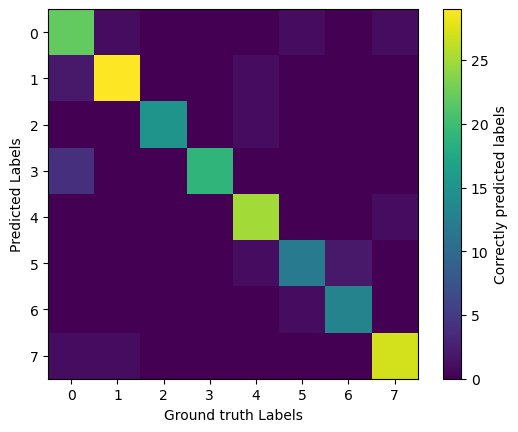

In [80]:
# TODO: select one model from Task 5, for example Random Forest
# selecting decision trees
model = models['Decision Tree']

# TODO: predict labels for X_test_large
y_large_test_predict = model.predict(X_large_test)

# TODO: create a crosstab with pd.crosstab(...)
crosstab = pd.crosstab(y_large_test_predict, y_large_test)
# TODO: display the crosstab

display(crosstab)

# TODO: plot the crosstab as a heatmap
plt.imshow(crosstab, cmap='viridis')
plt.colorbar(label='Correctly predicted labels')
plt.xlabel('Ground truth Labels')
plt.ylabel('Predicted Labels')
plt.show()


---
## Task 7 – Automatic hyperparameter optimization

So far, you trained classifiers mostly with their default settings. Many machine-learning algorithms have **hyperparameters**: settings that are chosen before training and can strongly influence the result. Examples are the maximum depth of a decision tree, the number of neighbors in k-NN, or the number and depth of trees in a random forest.

Trying these settings manually is slow and can easily become inconsistent. In this task, you let scikit-learn test several hyperparameter combinations automatically. The important point is that the search uses **cross-validation on the training data**. The test set should not be used to decide which hyperparameters are best.

You will optimize three algorithms and compare two common search strategies:

| Algorithm | Search strategy | Example hyperparameters |
|---|---|---|
| Decision Tree | `GridSearchCV` | `max_depth`, `min_samples_split`, `criterion` |
| k-NN | `RandomizedSearchCV` | `n_neighbors`, `weights`, `metric` |
| Random Forest | `RandomizedSearchCV` | `n_estimators`, `max_depth`, `min_samples_split` |

After the searches, compare the best cross-validation score of each optimized model with the default models from Task 3.

You will use these two search strategies:

### a) Grid Search
Searches **all** combinations in the defined grid.
```python
GridSearchCV(estimator, param_grid, cv=5, scoring='accuracy')
```

### b) Random Search
Samples **random** combinations from the search space (faster for large spaces).
```python
RandomizedSearchCV(estimator, param_distributions, n_iter=20, cv=5)
```

**Hints:**
- `.best_params_` shows the best parameters found
- `.best_score_` shows the best CV accuracy
- `.fit(X_train, y_train)` starts the search

In [ ]:
# TODO: Grid Search for Decision Tree
param_grid_dt = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
}
# grid_dt = GridSearchCV(...)
# grid_dt.fit(...)

# TODO: Random Search for k-NN
param_dist_knn = {
    "n_neighbors": range(1, 30),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
# rand_knn = RandomizedSearchCV(...)
# rand_knn.fit(...)

# TODO: Random Search for Random Forest
param_dist_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}
# rand_rf = RandomizedSearchCV(...)
# rand_rf.fit(...)


# TODO: print results and compare them with default models

---
## Task 8 – Evaluate the best model on the test set

Choose the best model from Task 7 and evaluate it on the test set.
In a clean ML workflow, the test set should be used only **once**, at the end. In this lab, you already inspected it in Task 3 for comparison; do not use the Task 3 test scores for hyperparameter tuning.

**Hint:** `best_estimator_` contains the already trained best model.

In [ ]:
# TODO: select the best model and evaluate it on X_test
# best_model = grid_dt.best_estimator_  (or rand_knn / rand_rf)
# test_acc = accuracy_score(y_test, best_model.predict(X_test))
# print(f"Test-Accuracy: {test_acc:.3f}")